In [1]:
import sys
from IPython.display import display, Javascript

def restart_kernel():
    """Restart the Jupyter Notebook kernel to reflect changes in modules and packages."""
    display(Javascript("Jupyter.notebook.kernel.restart()"))
    print("Kernel is restarting...")

restart_kernel()

import bptf
from bptf import BPTF
import numpy as np
import pandas as pd
import sparse
import os
import shutil
from tqdm import tqdm
import pickle
import gdelt
import scipy.stats as st
import matplotlib.pyplot as plt
import torch
import tensorly
import cupy

from datetime import datetime, timedelta

import multiprocessing
from joblib import Parallel, delayed
from tqdm.contrib.concurrent import process_map

import requests
from bs4 import BeautifulSoup

import copy

print(os.getcwd())

import gc
gc.collect()

<IPython.core.display.Javascript object>

Kernel is restarting...


here


/home/luiyusen/projects/bptf_new


20

In [2]:
gdelt_filepaths = [os.path.join('gdeltv1', f) for f in os.listdir('gdeltv1')]
gdelt1 = [pd.read_csv(
    gdelt_filepath, dtype={
        'Actor1CountryCode': str,
        'Actor2countryCode': str,
        'EventRootCode': np.int64,
        'SQLDATE': str,
        'NumMentions': np.int64
    },
    na_values='--'
) for gdelt_filepath in gdelt_filepaths]
gdelt1 = pd.concat(gdelt1)
print(f'data types: {gdelt1.dtypes}')

data types: Actor1CountryCode    object
Actor2countryCode    object
EventRootCode         int64
SQLDATE              object
NumMentions           int64
dtype: object


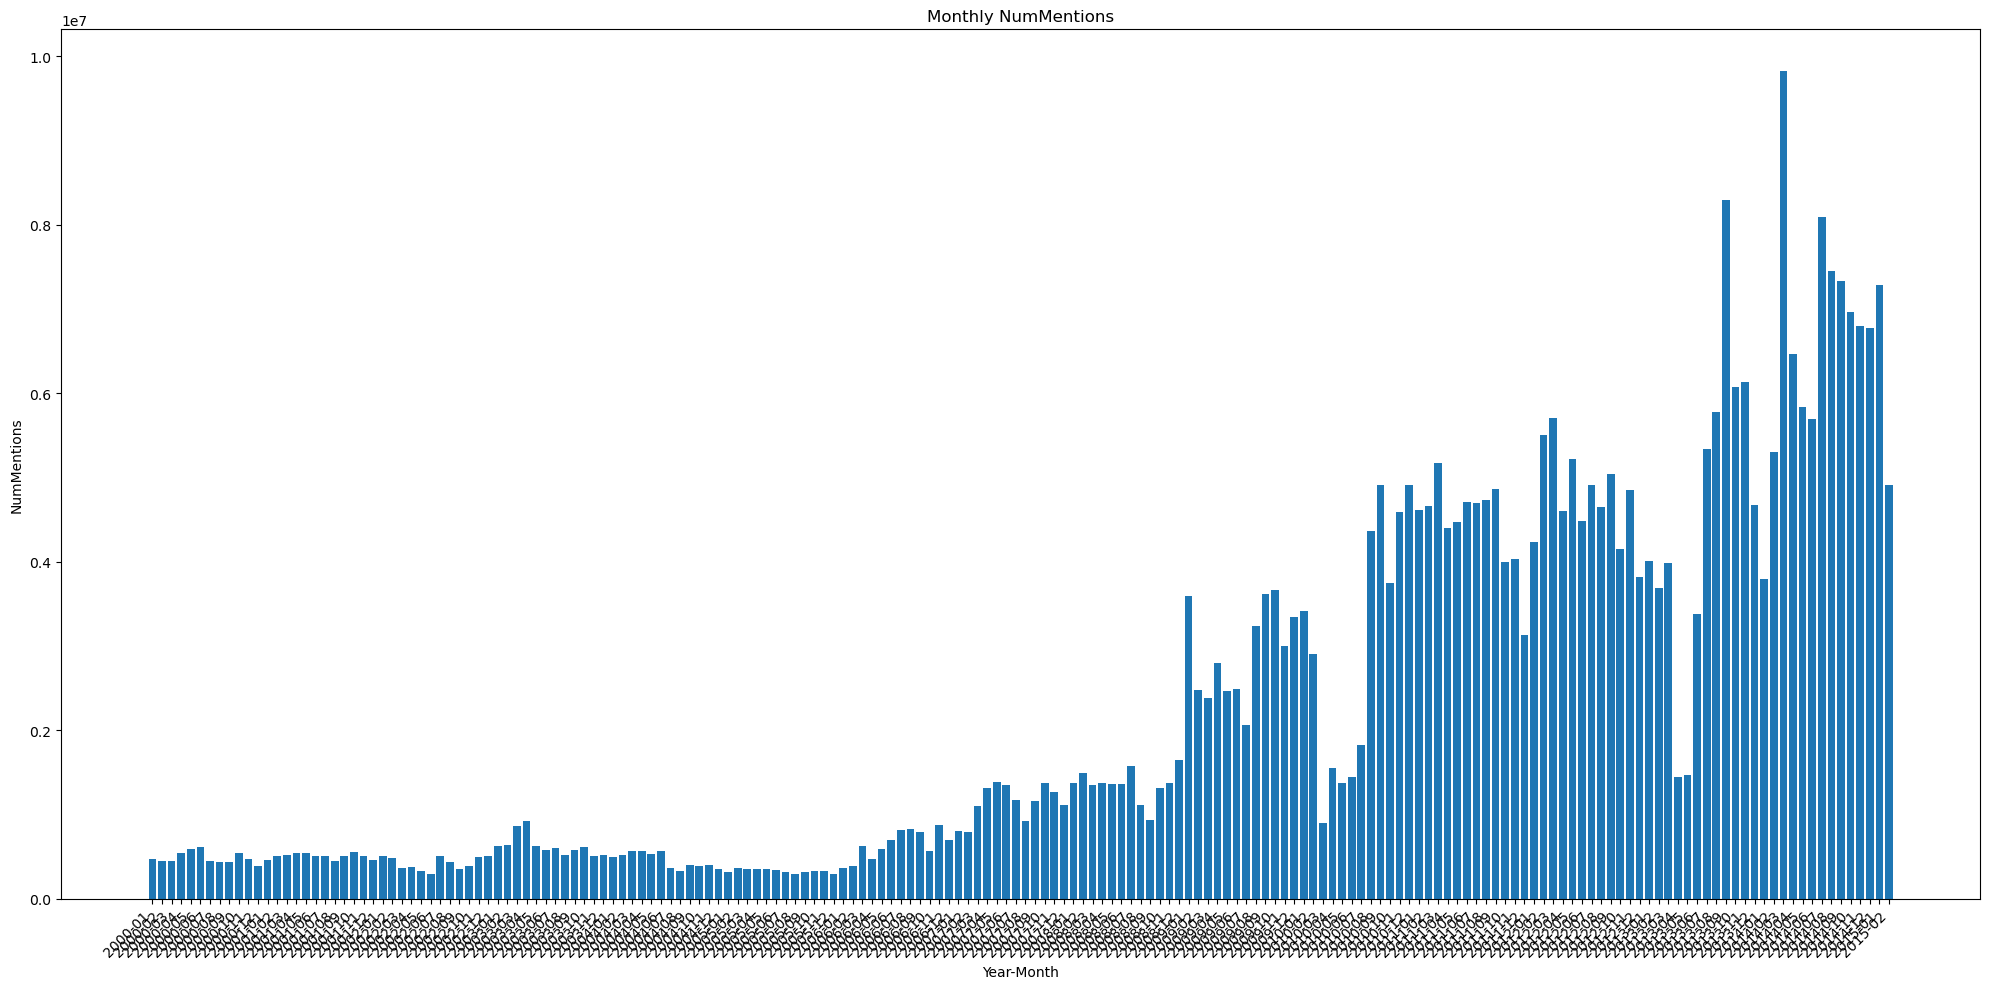

In [3]:
gdelt1_plot = gdelt1.copy()
gdelt1_plot['SQLDATE'] = pd.to_datetime(gdelt1_plot['SQLDATE'], format='%Y%m%d', errors='coerce')
gdelt1_plot['month_year'] = gdelt1_plot['SQLDATE'].dt.to_period('M')
gdelt1_plot = gdelt1_plot.groupby('month_year')['NumMentions'].sum()

plt.figure(figsize=(20, 10))
plt.bar(gdelt1_plot.index.astype(str), gdelt1_plot.values)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Year-Month')
plt.ylabel('NumMentions')
plt.title('Monthly NumMentions')
plt.tight_layout()
plt.show()

In [4]:
folder = "/icews_gdelt_terrier/"
data_filepath = os.getcwd() + folder
files = os.listdir(data_filepath)
data = [pd.read_csv(data_filepath + filepath) for filepath in files]
data = pd.concat(data)
data['formatteddate'] = pd.to_datetime(data['formatteddate'], format='%Y-%m-%d')
cutoff = pd.to_datetime('2015-02-18')
mask = ~((data['Database'] == 'GDELT') & (data['formatteddate'] <= cutoff))
data = data.loc[mask]
data['formatteddate'] = data['formatteddate'].dt.strftime('%Y-%m-%d')
print(f'data types: {data.dtypes}')

data types: Source_Country_Code    object
Target_Country_Code    object
CAMEO_Code              int64
formatteddate          object
Num_Events              int64
Database               object
dtype: object


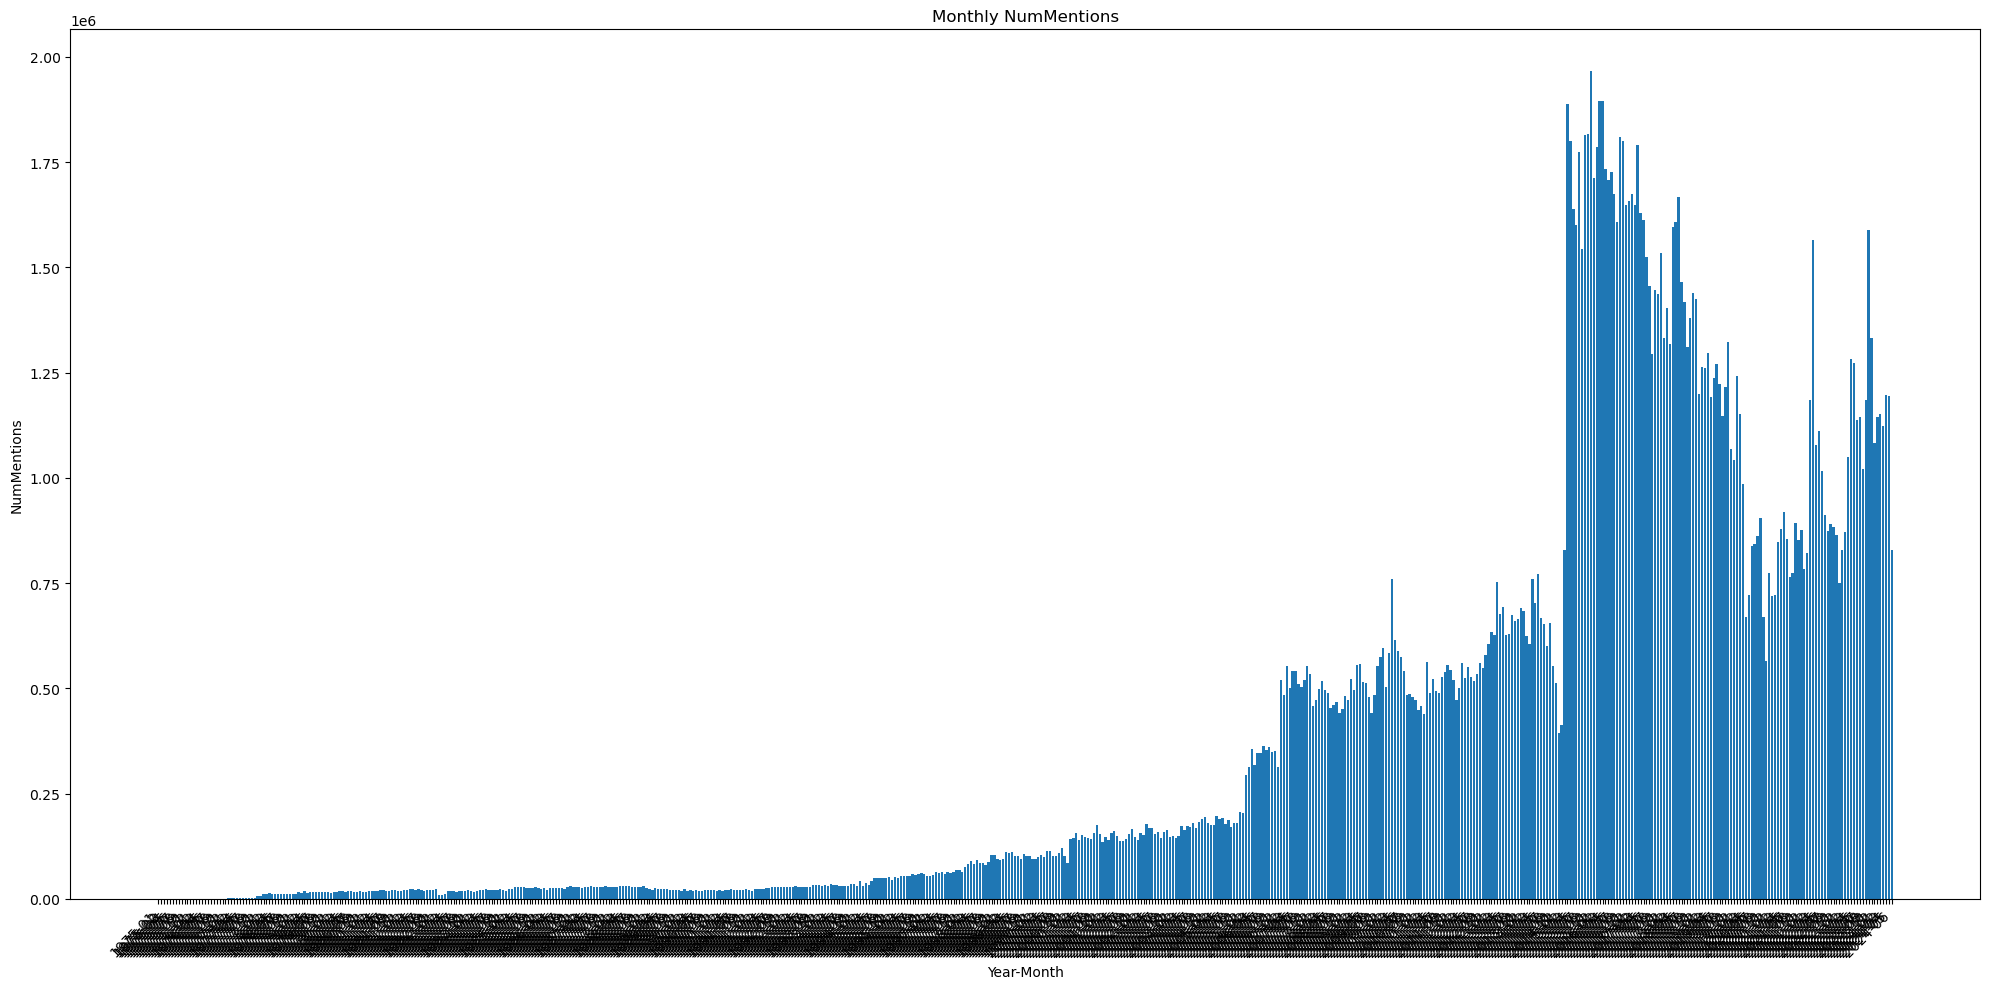

In [5]:
data_plot = data.copy()
data_plot['formatteddate'] = pd.to_datetime(data_plot['formatteddate'], format='%Y-%m-%d', errors='coerce')
data_plot['month_year'] = data_plot['formatteddate'].dt.to_period('M')
data_plot = data_plot.groupby('month_year')['Num_Events'].sum()

plt.figure(figsize=(20, 10))
plt.bar(data_plot.index.astype(str), data_plot.values)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Year-Month')
plt.ylabel('NumMentions')
plt.title('Monthly NumMentions')
plt.tight_layout()
plt.show()

In [6]:
unique_country_codes_data = data['Source_Country_Code'].dropna().unique()
unique_country_codes_data = set(sorted(unique_country_codes_data))

unique_country_codes_gdelt1 = gdelt1['Actor1CountryCode'].dropna().unique()
unique_country_codes_gdelt1 = set(sorted(unique_country_codes_gdelt1))

only_in_data = sorted(unique_country_codes_data - unique_country_codes_gdelt1)
only_in_gdelt1 = sorted(unique_country_codes_gdelt1 - unique_country_codes_data)

print(f'Only in data: {only_in_data}')
print(f'Only in gdelt1: {only_in_gdelt1}')

Only in data: ['ALA', 'ASM', 'ATA', 'ATF', 'BES', 'BIH', 'BLM', 'CCK', 'CUW', 'CXR', 'DDR', 'ESH', 'FLK', 'FRO', 'GGY', 'GIB', 'GLP', 'GRL', 'GUF', 'GUM', 'HMD', 'IGO', 'IMG', 'IMN', 'IOT', 'JEY', 'KSV', 'MAF', 'MNC', 'MNE', 'MNP', 'MSR', 'MTQ', 'MYT', 'NCL', 'NFK', 'NGO', 'NIU', 'PCN', 'PYF', 'REU', 'ROU', 'SGS', 'SJM', 'SPM', 'SUN', 'SVN', 'SXM', 'TCA', 'TKL', 'TLS', 'UMI', 'VGB', 'VIR', 'XKK', 'YUG']
Only in gdelt1: []


In [7]:
comparing_total_counts = pd.DataFrame({
    'Databases': ['ICEWS', 'TERRIER', 'GDELTv2', 'GDELTv1', 'GDELTv1 + GDELTv2'],
    'Number of events': [len(data[data['Database'] == 'ICEWS']), len(data[data['Database'] == 'TERRIER']), len(data[data['Database'] == 'GDELT']),
                         len(gdelt1), len(data[data['Database'] == 'GDELT']) + len(gdelt1)],
    'Number of counts': [data[data['Database'] == 'ICEWS']['Num_Events'].sum(), data[data['Database'] == 'TERRIER']['Num_Events'].sum(), 
                         data[data['Database'] == 'GDELT']['Num_Events'].sum(),
                         gdelt1['NumMentions'].sum(), data[data['Database'] == 'GDELT']['Num_Events'].sum() + gdelt1['NumMentions'].sum()]
})
print(comparing_total_counts)

           Databases  Number of events  Number of counts
0              ICEWS          12547851          17399387
1            TERRIER           8600127          66814516
2            GDELTv2          42834345         134893708
3            GDELTv1          45338323         400237242
4  GDELTv1 + GDELTv2          88172668         535130950


    EventRootCode  NumMentions
0               1     42783068
1               2     22945643
2               3     34041832
3               4    111186823
4               5     32493935
5               6     10709148
6               7     14645795
7               8     13750622
8               9      6559713
9              10      5423844
10             11     24234553
11             12      9493289
12             13      9050283
13             14      3479066
14             15      1938421
15             16      6106464
16             17     17115641
17             18      5721966
18             19     28399555
19             20       157581


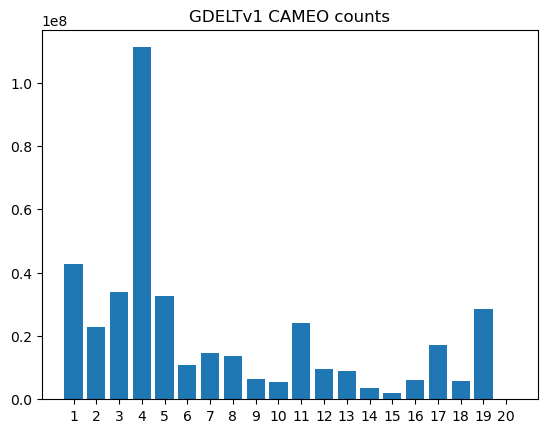

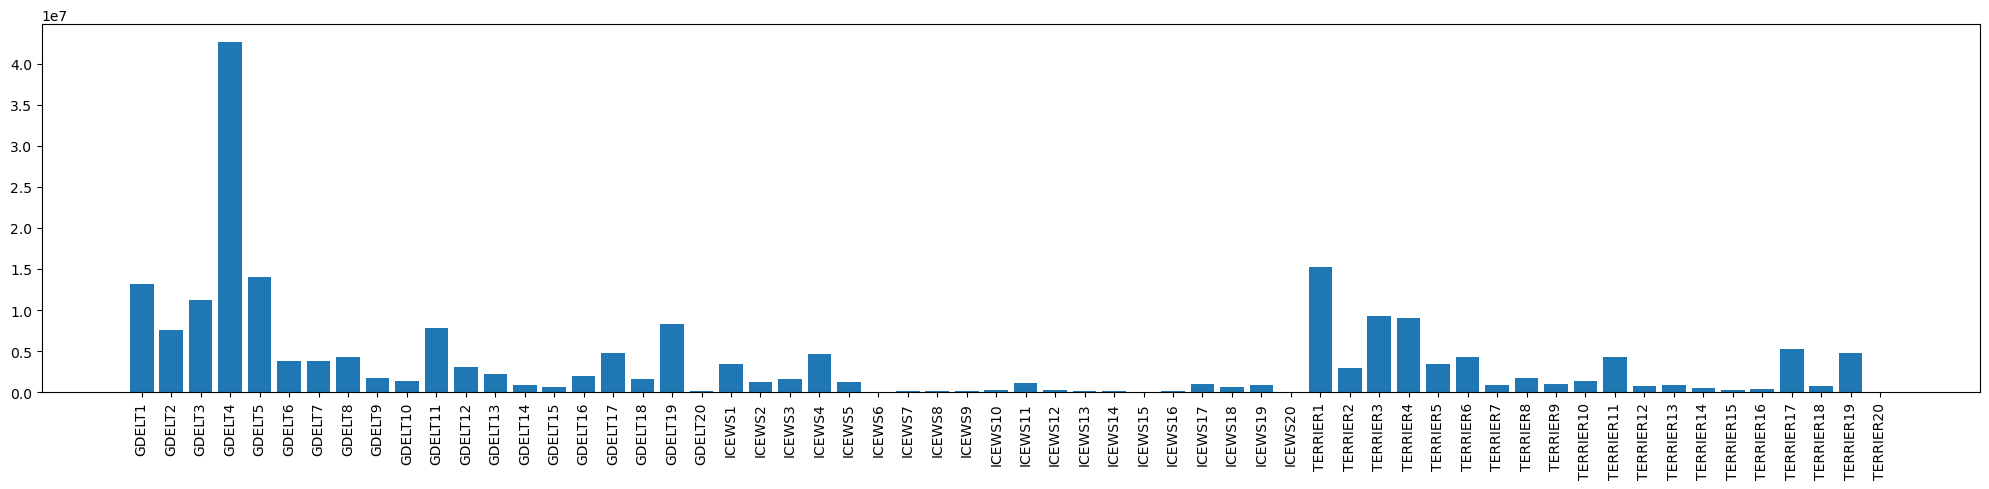

In [8]:
check_cameo_counts = gdelt1.groupby(['EventRootCode'], as_index = False).sum('NumMentions')
print(check_cameo_counts)
plt.bar(check_cameo_counts['EventRootCode'].astype(str), check_cameo_counts['NumMentions'])
plt.title('GDELTv1 CAMEO counts')
plt.show()

check_cameo_counts = data.groupby(['Database', 'CAMEO_Code'], as_index = False).sum('Num_Events')
check_cameo_counts['Database_CAMEO'] = check_cameo_counts['Database'] + check_cameo_counts['CAMEO_Code'].astype(str)
fig, ax = plt.subplots(figsize=(20, 5))
ax.bar(check_cameo_counts['Database_CAMEO'], check_cameo_counts['Num_Events'])
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()